# Anomaly detection on wind turbine power curve

# Index

1. **Initial Setup**
2. **Data Cleaning**
   - 2.1. Parsing numeric columns and handling errors
   - 2.2. Date parsing
   - 2.3. Removing nulls and inconsistent data
3. **Exploratory Data Analysis (EDA)**
   - 3.1. Distributions of power and wind speed
   - 3.2. Power curve visualization
4. **Feature Scaling and Sampling for DBSCAN**
5. **Hyperparameter Tuning for DBSCAN**
   - 5.1. Choosing minPts and k-distance plot
   - 5.2. Automatic eps selection
6. **Applying DBSCAN and Analyzing Results**
   - 6.1. Model training
   - 6.2. Filtering small clusters and visualization
   - 6.3. Separating normal data from anomalies
7. **Conclusions**

## 1. Initial setup
Import required libraries: pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for visualization.

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns

# Load the dataset
df = pd.read_csv('aero_final.csv', sep=',', thousands='.', decimal=',')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.info())

Dataset shape: (157824, 4)

First 5 rows:
                 Date Electrical_ActivePower Meteorological_WindSpeed  Turbine
0  01-ene-16 00:10:00      -9,47746063091524         1,02780303822881        1
1  01-ene-16 00:20:00      -8,92013817629341        0,811295253539813        1
2  01-ene-16 00:30:00      -5,34348285523723         1,37209751823404        1
3  01-ene-16 00:40:00      -6,61478073418776         1,42821059890001        1
4  01-ene-16 00:50:00      -8,03781741850159         1,90702276401743        1

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157824 entries, 0 to 157823
Data columns (total 4 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Date                      157824 non-null  object
 1   Electrical_ActivePower    157824 non-null  object
 2   Meteorological_WindSpeed  157824 non-null  object
 3   Turbine                   157824 non-null  int64 
dtypes: int64(1), object(3)
mem

The dataset contains 157,824 rows of 10-minute wind turbine data. All columns except `Turbine` are stored as strings (object type), and the decimal separator is a comma (`,`). Negative power values (physically impossible) are also present and will need to be handled.

Numeric columns are stored as `object` due to decimal commas and error messages. The `Turbine` column is integer.

In [3]:
# Find non-numerical data.
cols_to_check = ['Electrical_ActivePower', 'Meteorological_WindSpeed']

for col in cols_to_check:
    mask = pd.to_numeric(df[col].str.replace(',', '.', regex=False), errors='coerce').isna()
    non_numeric_values = df.loc[mask, col].unique()
    print(f'Non-numeric values in {col}:\n{non_numeric_values}\n')

Non-numeric values in Electrical_ActivePower:
['[-11059] No Good Data For Calculation']

Non-numeric values in Meteorological_WindSpeed:
['[-11059] No Good Data For Calculation']



We identify cells containing the message `[-11059] No Good Data For Calculation` in power and wind speed columns.
We should replace the decimal comma with a dot and force conversion to `float64` during the data cleaning. Non-convertible values become `NaN`.

## 2. Data Cleaning

### 2.1. Parsing numeric columns and handling errors

In [4]:
# Parse.
cols_to_convert = ['Electrical_ActivePower', 'Meteorological_WindSpeed']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col].str.replace(',', '.', regex=False), errors='coerce')    # Non-numerical values to NaN.

In [5]:
# Count missing values per column.
print('Missing values per column:')
display(df.isna().sum())

# Compute the percentage of missing values per column.
print('Percentage of missing values per column:')
display(df.isna().sum() / len(df) * 100)

Missing values per column:


Date                           0
Electrical_ActivePower      4757
Meteorological_WindSpeed    4885
Turbine                        0
dtype: int64

Percentage of missing values per column:


Date                        0.000000
Electrical_ActivePower      3.014117
Meteorological_WindSpeed    3.095220
Turbine                     0.000000
dtype: float64

Approximately 3% of power and wind speed data are missing (originating from error messages). `Date` and `Turbine` have no missing values.

In [6]:
# Inspect numerical data.
print('Summary statistics:')
display(df.describe())

Summary statistics:


,Electrical_ActivePower,Meteorological_WindSpeed,Turbine
count,153067.000000,152939.000000,157824.0
mean,447.160565,6.056609,1.0
std,586.110309,3.333022,0.0
min,-46.031400,0.524102,1.0
25%,-3.270159,3.510765,1.0
50%,184.050233,5.372944,1.0
75%,668.854857,7.797071,1.0
max,2005.175610,29.029226,1.0


We observe negative minimum power values (physically impossible) and a wide wind speed range (0.5 to 29 m/s).

### 2.2. Date parsing (Spanish to datetime) 

Months are in Spanish (ene, feb, ...). We replace them with numbers and parse to `datetime`.

In [7]:
months_dict = {
    'ene':'01', 'feb':'02', 'mar':'03',
    'abr':'04', 'may':'05', 'jun':'06',
    'jul':'07', 'ago':'08', 'sep':'09',
    'oct':'10', 'nov':'11', 'dic':'12'
}

df['Date'] = df['Date'].replace(months_dict, regex=True)
print('Date column after dictionary replacement:')
display(df['Date'].head(3))

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%y %H:%M:%S', errors='raise')
print('Date column after parsing:')
display(df['Date'].head(3))

Date column after dictionary replacement:


0    01-01-16 00:10:00
1    01-01-16 00:20:00
2    01-01-16 00:30:00
Name: Date, dtype: object

Date column after parsing:


0   2016-01-01 00:10:00
1   2016-01-01 00:20:00
2   2016-01-01 00:30:00
Name: Date, dtype: datetime64[ns]

In [8]:
# Check data types again.
print('Dataset info:')
display(df.dtypes)

Dataset info:


Date                        datetime64[ns]
Electrical_ActivePower             float64
Meteorological_WindSpeed           float64
Turbine                              int64
dtype: object

### 2.3. Removing nulls and inconsistent data

In [9]:
# Previous shape.
print(f'Shape before removing NaNs and duplicates: {df.shape}')

# Drop NaN values.
print(f'Number of NaN rows: {df.isna().any(axis=1).sum()}')
df = df.dropna()

# Drop duplicated rows.
print(f'Number of duplicated rows: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Final shape.
print(f'Final shape: {df.shape}')

Shape before removing NaNs and duplicates: (157824, 4)
Number of NaN rows: 4885
Number of duplicated rows: 0
Final shape: (152939, 4)


We drop rows with `NaN` (4885 rows) and duplicates (none found). Final shape: 152,939 records.

In [10]:
faulty_data = df[
    (df['Electrical_ActivePower'] <= 0) &
    (df['Meteorological_WindSpeed'] > 4) &
    (df['Meteorological_WindSpeed'] < 25)
].index

df = df.drop(faulty_data)
display(df)

,Date,Electrical_ActivePower,Meteorological_WindSpeed,Turbine
0,2016-01-01 00:10:00,-9.477461,1.027803,1
1,2016-01-01 00:20:00,-8.920138,0.811295,1
2,2016-01-01 00:30:00,-5.343483,1.372098,1
3,2016-01-01 00:40:00,-6.614781,1.428211,1
4,2016-01-01 00:50:00,-8.037817,1.907023,1
...,...,...,...,...
157819,2018-12-31 23:20:00,122.236200,4.299063,1
157820,2018-12-31 23:30:00,103.331784,3.853069,1
157821,2018-12-31 23:40:00,141.050908,4.139554,1
157822,2018-12-31 23:50:00,58.056792,3.721967,1


## 3. Exploratory Data Analysis (EDA)

### 3.1. Distributions of power and wind speed
We removed cases where power is ≤ 0 but wind speed > 4 m/s (region where the turbine should produce positive power). Then we visualize the distribution of active power and wind speed. Power has high frequency near zero and a second peak around 1000-1500 kW. Wind speed follows a positively skewed distribution.

c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


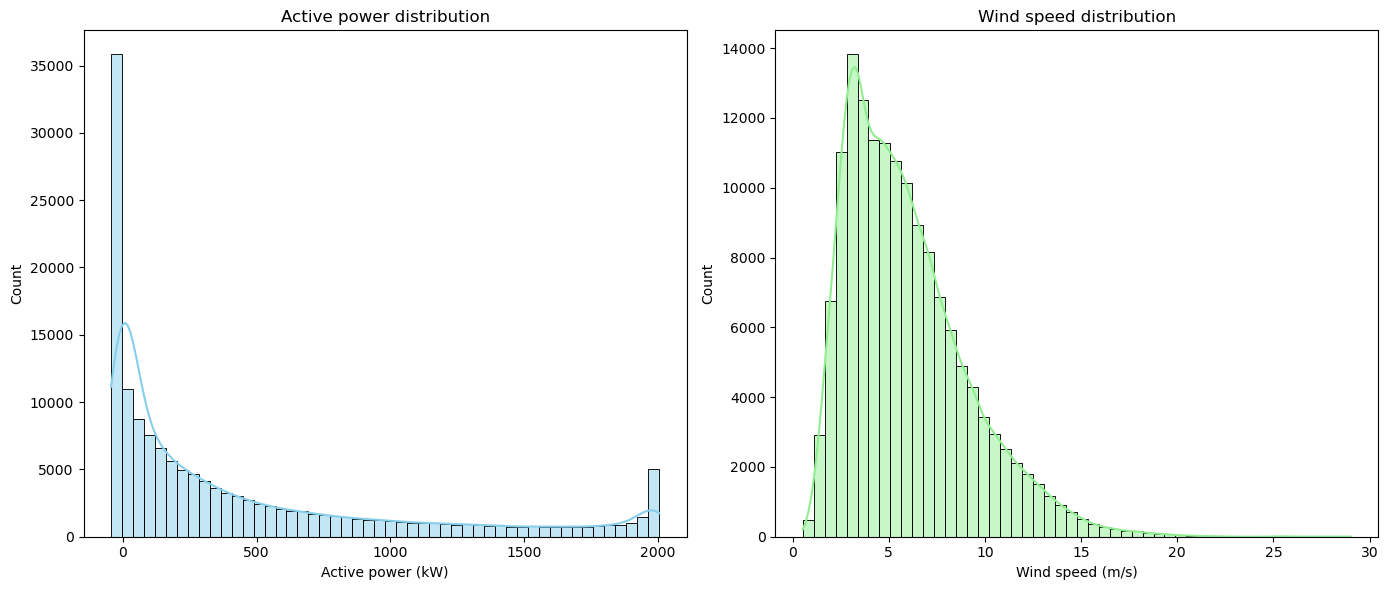

In [11]:
plt.figure(figsize=(14, 6))

# Histogram for 'Electrical_ActivePower'.
plt.subplot(1, 2, 1)
sns.histplot(df['Electrical_ActivePower'], bins=50, kde=True, color='skyblue')
plt.title('Active power distribution')
plt.xlabel('Active power (kW)')

# Histogram for 'Meteorological_WindSpeed'.
plt.subplot(1, 2, 2)
sns.histplot(df['Meteorological_WindSpeed'], bins=50, kde=True, color='lightgreen')
plt.title('Wind speed distribution')
plt.xlabel('Wind speed (m/s)')

plt.tight_layout()
plt.show()

We plot the expected relationship: higher wind speed (between 3-4 m/s up to 25 m/s) leads to higher power, with saturation near maximum. Points outside the main cloud are potential anomalies to be detected by DBSCAN.

### 3.2. Power curve visualization

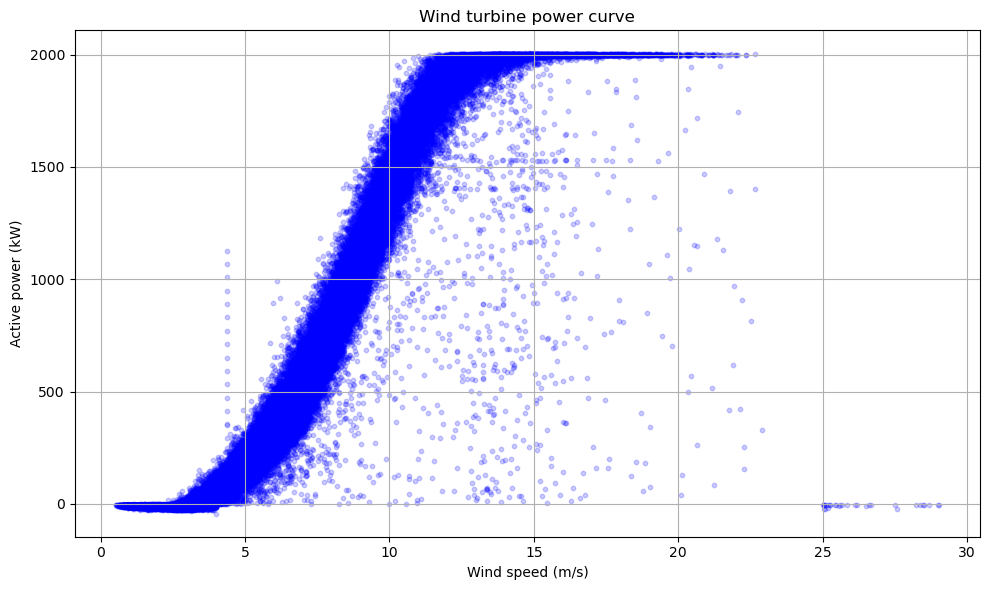

In [12]:
# Plot wind turbine curve.
plt.figure(figsize=(10, 6))
plt.scatter(
    df['Meteorological_WindSpeed'],
    df['Electrical_ActivePower'],
    alpha=0.2,
    s=10,
    c='blue'
)
plt.title('Wind turbine power curve')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Active power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

The scatter plot above shows the relationship between wind speed and active power. Under normal operating conditions, the turbine should follow a clear pattern. Below the cut‑in speed of approximately 3‑4 m/s, the power output is zero or near zero. Between 4 and 12 m/s, the power increases steadily with wind speed in what is known as the partial load region. From 12 up to 25 m/s, the power remains close to the rated maximum of around 2000 kW. Above 25 m/s, the turbine shuts down for safety reasons.

Any points that deviate from this expected pattern, such as negative power values or very low power at high wind speeds, are considered potential anomalies. In the following section, we will use the DBSCAN algorithm to automatically detect these anomalies. We will scale the wind speed and power data, apply DBSCAN to identify outliers, and finally visualise and interpret the detected anomalies.

## 4. Feature Scaling and Sampling for DBSCAN

Before applying DBSCAN, we need to scale the two features: wind speed and active power. Since DBSCAN relies on distance calculations, features with different units and ranges must be brought to a comparable scale. We use MinMaxScaler to transform both variables into the range [0, 1]. This ensures that neither feature dominates the distance computation due to its original magnitude.


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go

minmax_scaler = MinMaxScaler()
df_scaled = minmax_scaler.fit_transform(df[['Meteorological_WindSpeed', 'Electrical_ActivePower']])

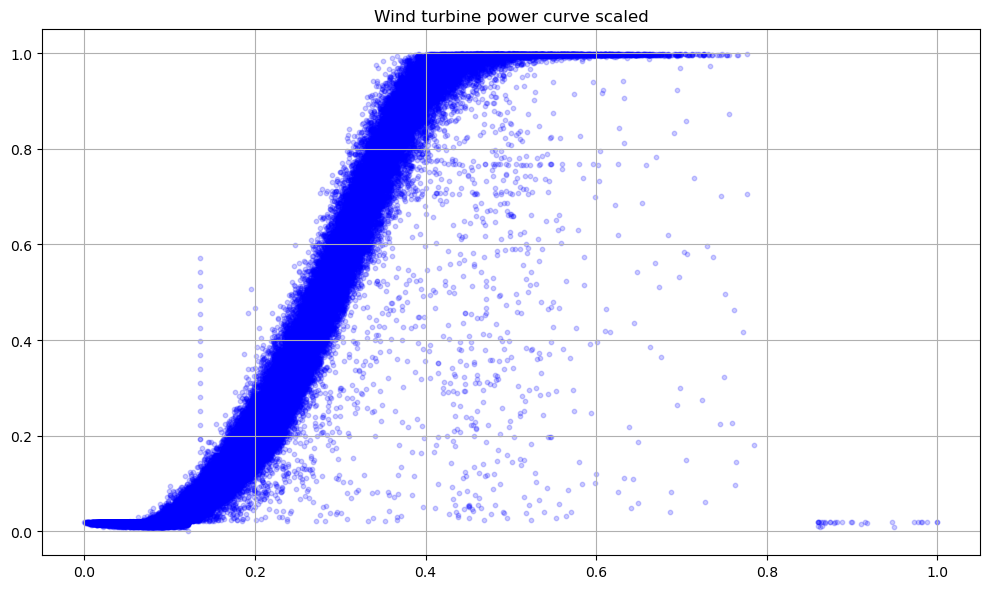

In [14]:
# Plot scaled data.
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scaled[:, 0],
    df_scaled[:, 1],
    alpha=0.2,
    s=10,
    c='blue'
)

plt.title('Wind turbine power curve scaled')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning for DBSCAN

Before applying DBSCAN to the full dataset, we need to choose appropriate values for its two main hyperparameters: `eps` (the maximum distance between two points to be considered neighbors) and `minPts` (the minimum number of points required to form a dense region). 

To speed up the tuning process, we create a stratified sample of the data. We first divide wind speed into bins of 2 m/s and then randomly sample 5% of the points from each bin. This preserves the overall shape of the power curve while reducing the computational cost of finding the best parameters.

In [15]:
# Reproducibility.
seed = 42
np.random.seed(seed)
random.seed(seed)

# Create wind speed bins.
df['WindSpeedBin'] = pd.cut(df['Meteorological_WindSpeed'], bins=np.arange(0, 26, 2))

# Stratified sampling: small fraction per bin (e.g., 5%).
df_strat_sample = (
    df.groupby('WindSpeedBin', group_keys=False)
    .apply(lambda x: x.sample(frac=0.05, random_state=seed))
)

minmax_scaler = MinMaxScaler()
df_strat_sample_scaled = minmax_scaler.fit_transform(df_strat_sample[['Meteorological_WindSpeed', 'Electrical_ActivePower']])

C:\Users\alexr\AppData\Local\Temp\ipykernel_21216\4005888266.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('WindSpeedBin', group_keys=False)


### 5.1. Choosing minPts and k-distance plot

To select an appropriate value for `eps`, we use the k‑distance graph. We set `minPts` equal to the number of features plus one, which is a common heuristic. For each point, we compute the distance to its k‑th nearest neighbor and sort these distances. The optimal `eps` is found at the "elbow" of the curve: the point where distances start to increase sharply. Points with distances beyond this threshold are potential anomalies.

In [16]:
# minPts

# Set minimum number of points to form a cluster.
minPts = df_strat_sample_scaled.shape[1] + 1
print(f'Minimum number of points to form a cluster: {minPts}')

Minimum number of points to form a cluster: 3


In [17]:
# Epsilon

# Use NearestNeighbors to compute distances to k-th nearest NearestNeighbors.
k = minPts
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_strat_sample_scaled)
distances, indices = neighbors_fit.kneighbors(df_strat_sample_scaled)

# Sort the distances to the k-th neighbor (use for elbow/knee method).
k_distances = np.sort(distances[:, -1])

# Plot the k-distance graph.
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=k_distances,
    mode='lines+markers',
    line=dict(color='royalblue'),
    marker=dict(size=5),
    name=f'{k}-th Nearest Neighbor Distance'
))

fig.update_layout(
    title=f'{k}-Distance plot (for ε selection)',
    xaxis_title=f'Points sorted by distance to {k}th nearest neighbor',
    yaxis_title='Distance',
    template='plotly_white',
    hovermode='x unified',
    height=400,
    width=800
)

fig.show()

### 5.2. Automatic eps selection

To select an appropriate value for `eps`, we first compute the k‑distance graph with `minPts = 3` (features + 1). Since the elbow is not visually clear in this dataset, we set `eps` automatically as the 95th percentile of the k‑distances. This means that points with distances greater than this threshold (approximately the 5% most isolated points) will be labeled as noise. The red vertical and horizontal lines in the plot below mark the chosen `eps` value and its corresponding position in the sorted distances.

In [18]:
# Set the maximum distance of the neighborhood.
eps = np.percentile(k_distances, 95)
index = np.where(k_distances >= eps)[0][0]
print(f'Maximum distance of the neighborhood: {eps}')

Maximum distance of the neighborhood: 0.006663776167868207


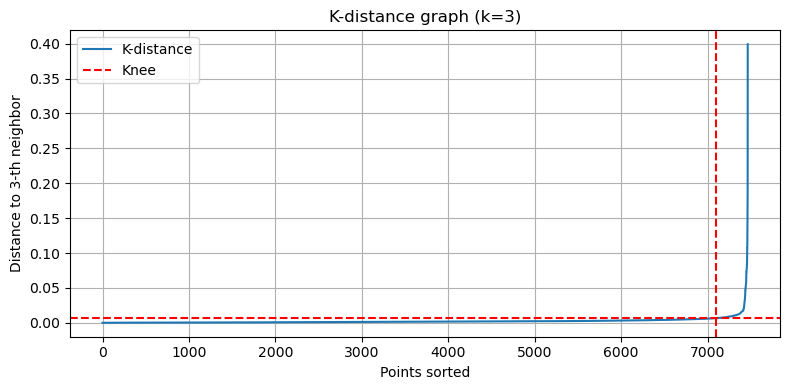

In [19]:
plt.figure(figsize=(8, 4))

plt.plot(k_distances, label='K-distance')
plt.axvline(x=index, color='r', linestyle='--', label='Knee')
plt.axhline(y=eps, color='r', linestyle='--')

plt.title(f'K-distance graph (k={k})')
plt.xlabel('Points sorted')
plt.ylabel(f'Distance to {k}-th neighbor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The optimal `eps` value obtained using the 95th percentile method is approximately **0.00666**. This threshold is represented by the horizontal red line in the plot above. The vertical red line indicates the position in the sorted distance list where this value is reached. Points lying to the right of this vertical line (approximately 5% of the sample) have distances greater than `eps` and will be treated as noise in the DBSCAN model.

With both hyperparameters now defined (`minPts = 3` and `eps ≈ 0.00666`), we are ready to apply DBSCAN to the full dataset and identify anomalous points on the wind turbine power curve.

## 6. Applying DBSCAN and Analyzing Results
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed together and marks points that lie alone in low-density regions as outliers. Unlike k-means, it does not require specifying the number of clusters beforehand and can identify noise points.

### 6.1. Model training
We will apply DBSCAN to the scaled dataset using the hyperparameters determined in the previous section: `eps = 0.00666` and `min_samples = 3`.

In [20]:
# Set ε based on the k-distance plot, and min_samples based on data.
db_tuned = DBSCAN(eps=eps, min_samples=minPts)
df['DBSCAN_Cluster'] = db_tuned.fit_predict(df_scaled)
display(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0     148340
-1        732
 21        14
 36        11
 29         9
 18         9
 10         6
 13         6
 3          6
 34         6
 32         5
 19         5
 14         5
 11         5
 22         5
 17         5
 7          5
 38         4
 28         4
 35         4
 1          4
 46         4
 37         4
 44         4
 2          4
 31         4
 12         4
 6          4
 8          4
 23         3
 43         3
 4          3
 50         3
 48         3
 45         3
 16         3
 53         3
 40         3
 39         3
 47         3
 55         3
 5          3
 26         3
 20         3
 42         3
 15         3
 33         3
 9          3
 30         3
 51         3
 52         3
 41         3
 54         3
 27         3
 25         3
 24         3
 49         3
Name: count, dtype: int64

The `DBSCAN_Cluster` column contains the cluster assignment for each point. Points labeled as `-1` are considered anomalies (noise), while points with labels `0`, `1`, `2`, etc. belong to different dense regions. 

The `value_counts()` output shows that DBSCAN has identified multiple clusters, some of which may contain very few points. To create a cleaner visualization, we filter out clusters smaller than a minimum size threshold (e.g., 10 points). This removes spurious tiny clusters that may not represent meaningful patterns. The `-1` label (noise) is also excluded from the main plot since anomalies will be visualized separately.

### 6.2. Filtering small clusters and visualization

DBSCAN_Cluster
0     148340
21        14
36        11
Name: count, dtype: int64

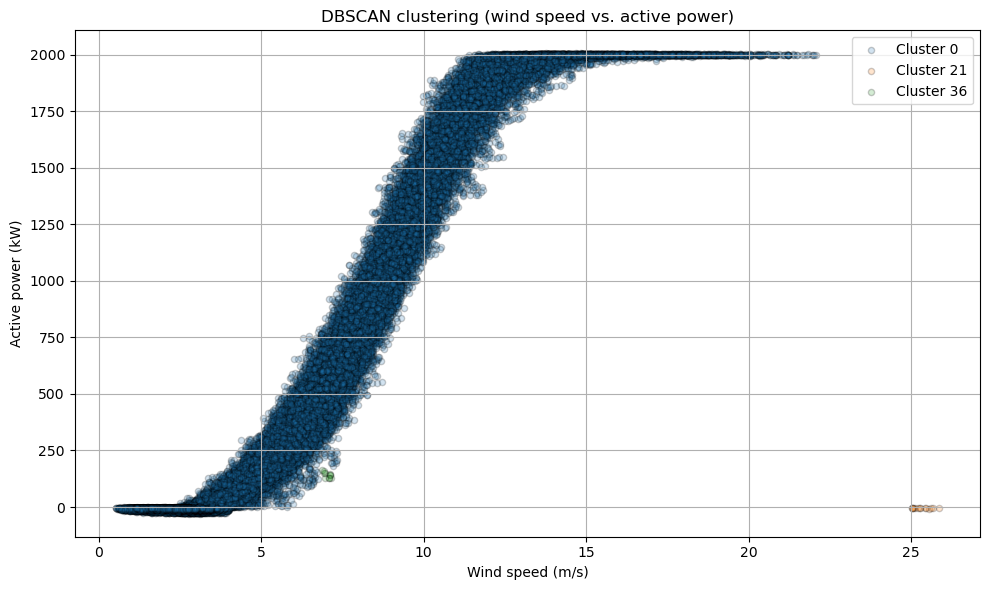

In [21]:
# Count how many points per label.
label_counts = df['DBSCAN_Cluster'].value_counts()

# Choose a minimum size threshold.
min_cluster_size = 10

# Get labels (excluding noise -1) with enough points.
valid_labels = label_counts[label_counts >= min_cluster_size].index
valid_labels = valid_labels[valid_labels != -1]

# Filter the DataFrame to keep only those labels.
df_filtered = df[df['DBSCAN_Cluster'].isin(valid_labels)]
display(df_filtered['DBSCAN_Cluster'].value_counts())

# Plot each cluster with a different color.
unique_labels = np.unique(df_filtered['DBSCAN_Cluster'])

plt.figure(figsize=(10, 6))

for label in unique_labels:
    cluster = df_filtered[df_filtered['DBSCAN_Cluster'] == label]
    plt.scatter(
        cluster['Meteorological_WindSpeed'],
        cluster['Electrical_ActivePower'],
        s=20,
        label=f'Cluster {label}' if label != -1 else 'Noise',
        alpha=0.2,
        edgecolor='k'
    )

plt.title('DBSCAN clustering (wind speed vs. active power)')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Active power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

DBSCAN_Cluster
0     148340
21        14
36        11
Name: count, dtype: int64

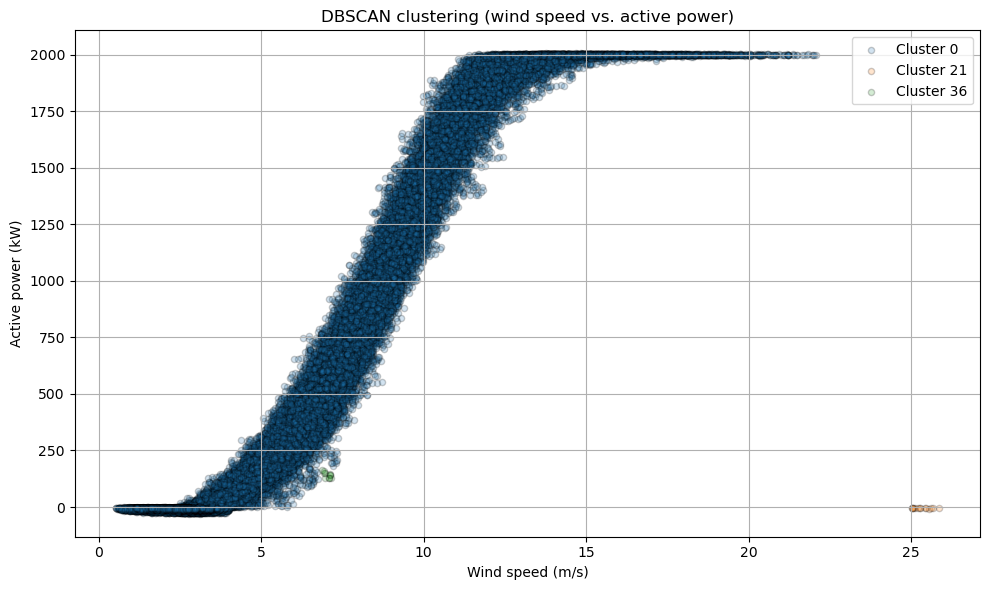

In [22]:
display(df_filtered['DBSCAN_Cluster'].value_counts())

# Plot each cluster with a different color.
unique_labels = np.unique(df_filtered['DBSCAN_Cluster'])

plt.figure(figsize=(10, 6))

for label in unique_labels:
    cluster = df_filtered[df_filtered['DBSCAN_Cluster'] == label]
    plt.scatter(
        cluster['Meteorological_WindSpeed'],
        cluster['Electrical_ActivePower'],
        s=20,
        label=f'Cluster {label}' if label != -1 else 'Noise',
        alpha=0.2,
        edgecolor='k'
    )

plt.title('DBSCAN clustering (wind speed vs. active power)')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Active power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The scatter plot above shows the main clusters detected by DBSCAN. Each color represents a different dense region in the wind-power curve. The clusters naturally follow the expected turbine behavior: low power at low wind speeds, increasing power in the mid-range, and saturation near maximum power. Points that do not belong to any large cluster (noise) are not shown here; they will be analyzed in the next step.

From the cluster visualization, we observe that **Cluster 0** represents the main dense region of the power curve, following the expected turbine behavior. The remaining clusters (Clusters 21, 36, etc.) and the noise points (`-1`) deviate from this pattern. These can be considered potential anomalies or atypical operating conditions.

We now separate Cluster 0 as the "normal" reference and group all other points as "anomalies" for a clearer comparison.

### 6.3. Separating normal data from anomalies

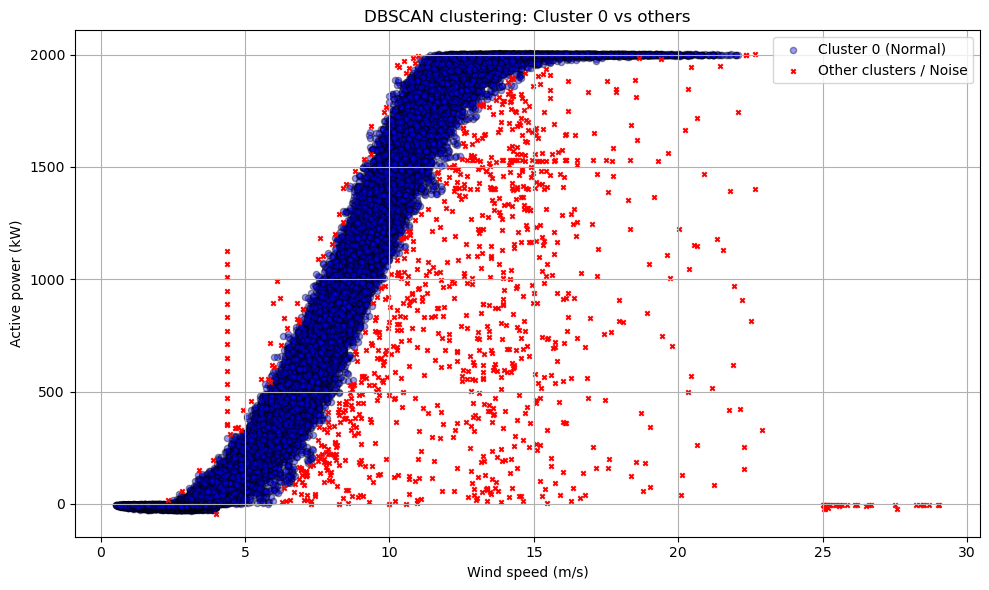

In [23]:
# Cluster 0 as normal and all other clusters as anomalies.
normal = df[df['DBSCAN_Cluster'] == 0]
anomalies = df[df['DBSCAN_Cluster'] != 0]

# Plot.
plt.figure(figsize=(10, 6))

plt.scatter(
    normal['Meteorological_WindSpeed'],
    normal['Electrical_ActivePower'],
    c='blue',
    label='Cluster 0 (Normal)',
    s=20,
    alpha=0.4,
    edgecolor='k'
)

plt.scatter(
    anomalies['Meteorological_WindSpeed'],
    anomalies['Electrical_ActivePower'],
    c='red',
    marker='x',
    label='Other clusters / Noise',
    s=10
)

plt.title('DBSCAN clustering: Cluster 0 vs others')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Active power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot above highlights the clear distinction between normal operating points (blue) and anomalous points (red). Normal points follow the expected power curve, while anomalies include:

- Points with negative or zero power at moderate to high wind speeds
- Points with very low power in regions where high power is expected
- Points far from the main dense region

These anomalies may indicate measurement errors, sensor malfunctions, turbine shutdowns, or other irregular events.

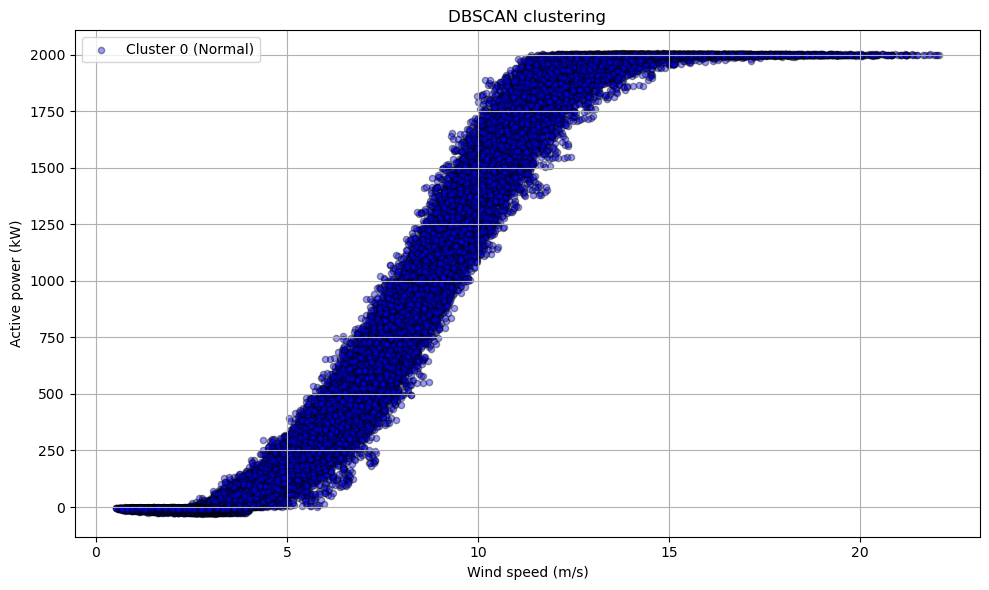

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    normal['Meteorological_WindSpeed'],
    normal['Electrical_ActivePower'],
    c='blue',
    label='Cluster 0 (Normal)',
    s=20,
    alpha=0.4,
    edgecolor='k'
)

plt.title('DBSCAN clustering')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Active power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot above shows only the points belonging to **Cluster 0**, which represents the main dense region of the power curve. These points follow the expected turbine behavior: power increases with wind speed from approximately 4 m/s up to the rated power around 12-13 m/s, then remains stable near the maximum. This cluster can be interpreted as the "normal operating regime" of the wind turbine. Anomalies and other clusters have been excluded for clarity, focusing solely on the typical performance pattern.

## 7. Conclusions

**Summary of the workflow**

This notebook implemented an unsupervised anomaly detection pipeline for wind turbine power curves using DBSCAN. The workflow consisted of: (1) data cleaning and EDA to understand the expected power-wind speed relationship, (2) feature scaling and stratified sampling to optimize DBSCAN hyperparameters, (3) hyperparameter tuning via k-distance graph with automatic `eps` selection (95th percentile), and (4) model application, clustering visualization, and separation of normal vs. anomalous points.

**Key findings**

DBSCAN successfully identified a large, dense cluster (Cluster 0) representing normal turbine operation, where power increases with wind speed from cut-in (~4 m/s) to rated power (~12-13 m/s), then stabilizes near maximum. The remaining points (other clusters and noise labeled -1) represent anomalous conditions, including negative power values at moderate-to-high wind speeds, very low power in regions where high power is expected, and points far from the main density region.

**Effectiveness of the approach**

The automatic `eps` selection using the 95th percentile of k-distances proved practical when no clear elbow was visible, avoiding subjective manual tuning. Stratified sampling by wind speed bins preserved the power curve shape while reducing computational cost during hyperparameter search. Removing clusters with fewer than 10 points cleaned the visualization without losing meaningful patterns.

**Limitations and future work**

The choice of `minPts = n_features + 1` is a heuristic; other values could be explored via domain knowledge or grid search. The 95th percentile threshold for `eps` is somewhat arbitrary and could be adjusted based on desired sensitivity. Future work could include temporal analysis of anomalies (e.g., detecting when failures occur over time), comparison with other algorithms (e.g., Isolation Forest, LOF), and integration with SCADA alarm logs for validation.